**Graph with MessageState and Tool Calling**

- Powerful graph that combines all the concepts:
1. It uses MessageState to manage conversation history
2. LLM to decide to call tools
3. Uses conditional edge(tools_condition) to route to the Toolnode if LLM calls a tool.

In [ ]:
from typing import Annotated, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages, AnyMessage
from langchain_tavily import TavilySearch
from langchain_groq import ChatGroq
from langchain_core.tools import tool
import os
from dotenv import load_dotenv

#environment variables
load_dotenv()

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
# Define some tools(e.g Web Search , custom functions)
# We are using Tavily Search for real time results
#Using the new TavilySearch class
tavily_tool = TavilySearch(
    max_results=3,
    search_depth="basic",  # Options: "basic" or "advanced"
    include_answer=False,   # Include AI-generated answer
    include_raw_content=False,  # Include full page content
    include_images=False    # Include images in results
)

@tool
def multiply(a:int,b:int)->int:
    """this tool will do multiplication"""
    return a*b

@tool
def add(a:int, b:int) -> int:
    "Add two integers"
    return a+b

tools_list=[tavily_tool, multiply, add]

# llm setup
llm = ChatGroq (
    temperature=0.3,
    groq_api_key=os.getenv("GROQ_API_KEY"),
    model_name="llama-3.3-70b-versatile"
)

# Bind tools to LLM
llm_with_tool=llm.bind_tools(tools_list)



- Ensure to use a "good_reasoning_model" while binding tools to ensure accurate decision making, effective task orchestration, and reliable tool invocation based on context.

- ToolNode is a pre-build class that wraps external tools or functions. 

- Triggered when a tool call is detected, enablng the agent to execute the appropriate functoion and return the result to the workflow.


In [4]:
# Define the state for our conversational agent
class State(TypedDict):
    messages : Annotated[list[AnyMessage], add_messages]   #This allows us to append our messages to the graph state

#Node for the LLM chatbot
def llm_chatbot(state: State):
    # Invoke the LLM with the current message history
    return {'messages': [llm_with_tool.invoke(state['messages'])]}


# ToolNode below will run the tools requested by the last AIMessage
# If there are multiple tools called, it will run in parallel
tool_node=ToolNode(tools_list)   # Accepts a list of tools

**tools_condition**---->  is a pre-built LangGraph function that checks if the last state message includes a tool call. If it does it routes to the tools node for execution

In [5]:
# Build the StateGraph
build=StateGraph(State)

# Adding our nodes
build.add_node('LLM', llm_chatbot)
build.add_node('tools', tool_node)

# Connect the nodes
build.add_edge(START, 'LLM') # Start by sending user input to the LLM


# Add a conditional edge from 'LLM'
build.add_conditional_edges(
    "LLM",
    tools_condition, # if last message from AI is tool call route to tool_node
    # Default mapping for tools_condition is {'tools':'tools_node_name'}
)

build.add_edge('tools', 'LLM')  # After tools run, send results back to the LLM for next turn

app=build.compile()

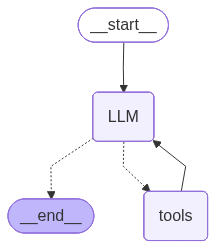

In [6]:
#Now lets visualize the flow of our graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
app.invoke({'messages':'Hey There'})

{'messages': [HumanMessage(content='Hey There', additional_kwargs={}, response_metadata={}, id='4cd347d0-384e-49ea-9e15-17d5a922dd9c'),
  AIMessage(content="I'm here to help with any questions or tasks you may have. What's on your mind?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 1790, 'total_tokens': 1811, 'completion_time': 0.065307643, 'completion_tokens_details': None, 'prompt_time': 0.103479541, 'prompt_tokens_details': None, 'queue_time': 0.057104521, 'total_time': 0.168787184}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d2ec3-e023-7f50-856d-2708049f877e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1790, 'output_tokens': 21, 'total_tokens': 1811})]}

In [8]:
app.invoke({'messages':'Who is the president of USA'})

{'messages': [HumanMessage(content='Who is the president of USA', additional_kwargs={}, response_metadata={}, id='caadafcb-2bee-4288-b7b7-3ce094371493'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ax2ckjrhy', 'function': {'arguments': '{"query":"President of USA","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 1794, 'total_tokens': 1818, 'completion_time': 0.093899761, 'completion_tokens_details': None, 'prompt_time': 0.284045203, 'prompt_tokens_details': None, 'queue_time': 0.265979894, 'total_time': 0.377944964}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d2ec4-7a94-7022-a595-9019b994fcf2-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'President of USA', 'topic': 'news'}, 'id': 'ax2ckjrhy', 'type': '

We build an Agent that can:
1. Maintain a conversation(MessageState)
2. Intelligently decide when to use tools(tools_condition)
3. Execute those tools(ToolNode)
4. Incorperate tool results back into reasoning